<a href="https://colab.research.google.com/github/27Kushal/PyTorch-learning/blob/main/pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn #nn contains pytorch building blocks for neural network
import matplotlib.pyplot as plt
import numpy as np
#checking pytorch version
torch.__version__

'2.9.0+cpu'

## Creating Data
Data can be in any format.

Machine learning is of 2 parts:
1. Get data into numerical representation
2. build a model to learn patterns in that numerical representation.

For creating some known data we would use a linear regression formula(similar to straight line formula) with known parameters

In [ ]:
#creating known parameters
weight=0.7
bias=0.3

#create
start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X+bias

X[:10],y[:10],len(X),len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

## Splitting data into training and testing sets




In [ ]:
#create a train/test split
#simplest way to do it
train_split=int(0.8*len(X))
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]

We cannot visualize so many data points so we use matplotlib to visualize data


In [ ]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """Plots training data and test data and compare predictions"""
  plt.figure(figsize=(10,7))
  #plot training data in blue
  plt.scatter(train_data,train_labels,c="b",s=4,label="Training Data")
  #plot test data in green
  plt.scatter(test_data,test_labels,c="g",s=4,label="Testing Data")

  #are there predictions?
  if predictions is not None:
    #plot predictions in red
    plt.scatter(test_data,predictions,c="r",s=4,label="Predictions")
  #show the legend
  plt.legend(prop={"size":14})

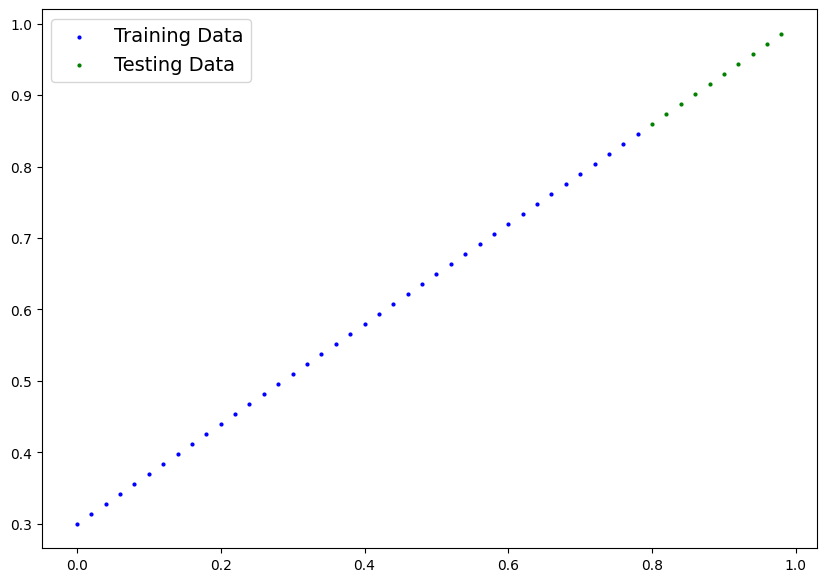

In [ ]:
plot_predictions()

## Building our first model

What our model does:
* start with random values of weights and bias
* look at training data and adjust the random values to better represent the ideal values

How does it do it:
* gradient descent
* backpropagation

In [ ]:
from torch import nn
#creating linear regression model
class LinearRegressionModel(nn.Module): # almost everthing in pytorch inherits from nn.Module
  def __init__(self):
    super().__init__()
    self.weights=nn.Parameter(torch.randn(1,  #start with a random weight then adjust it to an ideal weight
                                          requires_grad=True, #can this parameter be updated via gradient descent?
                                          dtype=torch.float))
    self.bias=nn.Parameter(torch.randn(1,   # starts with random bias and adjusts it to ideal bias
                                        requires_grad=True,
                                        dtype=torch.float))
  #Forward method to define the computation in the model
  def forward(self,x:torch.Tensor) -> torch.Tensor: # <- "x" is the input data
    return self.weights * x+self.bias #this is the linear regression formula

### Pytorch model building essentials

* torch.nn - contains all the buildings for computational graphs(another word for neural networks)
* torch.nn.Parameter - what parameters should our model try and learn, often a pytorch layer from torch.nn will set these for us
* torch.nn.Module - The base class for all neural network modules, if you subclass it then you should overwrite forward()
* torch.optim- this is where the optimizers in Pytorch live, they help with gradient descent
* def forward()- all nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation

### checking the contents of our pytorch model
we can check whats inside our model using .parameters()

In [ ]:
#creating a random seed
torch.manual_seed(42)
#creating an instance of the model (this is a subclass of nn.Module)
model_0=LinearRegressionModel()
#check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
#list named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predictions using torch.inference_mode()
To check out model's predictive power, let's see how it predicts y_test based on x_test
When we pass data through our model, it's going to run through the forward() method

In [ ]:
#make predictions with our model
with torch.inference_mode(): # helps in faster prediction of the data
  y_preds=model_0(X_test)
# same thing could be done using torch.no_grad() but inference_mode is preferred
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

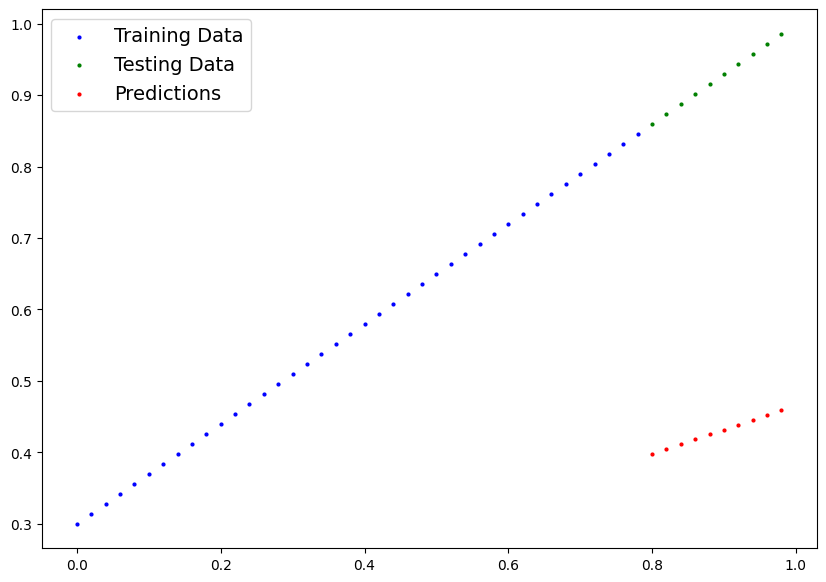

In [ ]:
plot_predictions(predictions=y_preds)

# Training our model
The whole idea of training is to move from some unknown parameters which can be random to known parameters
or from poor representation of the data to better representation of the same

To measure how poor or how wrong our models predictions are is to use a loss function

Things we need to train:
* loss function- calculating how wrong the model is
* optimizer- takes into account the loss of the model and adjusts the model's parameter to improve the loss function
  * in optimizers you need to set 2 parameters
    * params- the model parameters you would like to optimize
    * lr- learning rate(hyperparameter)- it defines how big or small the optimizer changes the parameters with each step

And specifically for Pytorch we need:
* a training loop
* a testing loop


In [ ]:
#setup a loss function
loss_fn=nn.L1Loss()

#setup an optimizer(stochastic gradient descent)
optimizer=torch.optim.SGD(params=model_0.parameters(),
                          lr=0.01) #lr=learning rate(most important hyperparameter)

# Building a training loop(and a testing loop)

Things we need in a training loop
* loop through the data  
* forward pass(this involves moving our data through our model's forward function) to make predictions on the data- also called forward propagation
* calculate the loss(compare the forward pass predictions to ground truth labels
* optimizer zero grad
* loss backwards - move backwards through the network to calculate the gradients (**backpropagation**)
* optimize our step- adjust model parameters to try and improve the loss(**gradient descent**)

In [ ]:
torch.manual_seed(42)
# an epoch is one loop through the data(its a hyperparameter)
epochs=200
#track different values
epoch_count=[]
train_loss_values=[]
test_loss_values=[]

#looping throught the data
for epoch in range(epochs):

  #set the model to training mode
  model_0.train() #train mode in pytorch sets all the parameters that requires gradients to require gradients

  #forward pass
  y_pred=model_0(X_train)

  #calculate the loss
  loss=loss_fn(y_pred,y_train)
  # optimizer zero grad
  optimizer.zero_grad()

  #perform backpropagation on the loss with respect to the parameters of the model
  loss.backward()

  #step the optimizer(perform gradient descent)
  optimizer.step() # by default the optimizer changes will accumulate through the loop so we have to zero them above in zero grad
  #optimizers gradient for better prediction

  ###testing
  model_0.eval()
  #turns off different settings in the model not needed for evaluation/testing
  with torch.inference_mode():
    #1.do forward pass
    test_pred=model_0(X_test)
    #2. calculate the loss
    test_loss=loss_fn(test_pred,y_test)

  #printing out what is happening
  if epoch%10==0:
    epoch_count.append(epoch)
    train_loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch}, Loss: {loss}, Test_loss: {test_loss}")
    print(model_0.state_dict())


Epoch: 0, Loss: 0.31288138031959534, Test_loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10, Loss: 0.1976713240146637, Test_loss: 0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20, Loss: 0.08908725529909134, Test_loss: 0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30, Loss: 0.053148526698350906, Test_loss: 0.14464017748832703
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40, Loss: 0.04543796554207802, Test_loss: 0.11360953003168106
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50, Loss: 0.04167863354086876, Test_loss: 0.09919948130846024
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60, Loss: 0.03818932920694351, Test_loss: 0.08886633068323135
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 70, Loss: 0.03476089984178543

In [ ]:
np.array(torch.tensor(train_loss_values).detach().numpy()) #converting tensors to numpy for plotting

/tmp/ipython-input-3844767685.py:1: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  np.array(torch.tensor(train_loss_values).detach().numpy()) #converting tensors to numpy for plotting


array([0.31288138, 0.19767132, 0.08908726, 0.05314853, 0.04543797,
       0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ,
       0.02445896, 0.02102021, 0.01758547, 0.01415539, 0.01071659,
       0.00728353, 0.00385178, 0.00893248, 0.00893248, 0.00893248],
      dtype=float32)

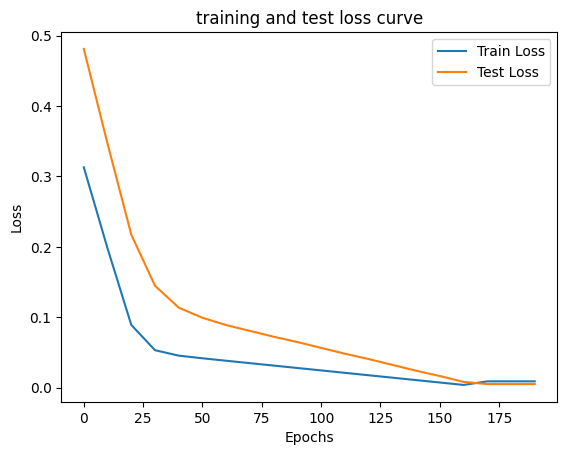

In [ ]:
#plotting the loss curve
plt.plot(epoch_count,np.array(torch.tensor(train_loss_values).detach().numpy()),label="Train Loss")
plt.plot(epoch_count,np.array(torch.tensor(test_loss_values).detach().numpy()),label="Test Loss")
plt.title("training and test loss curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend();

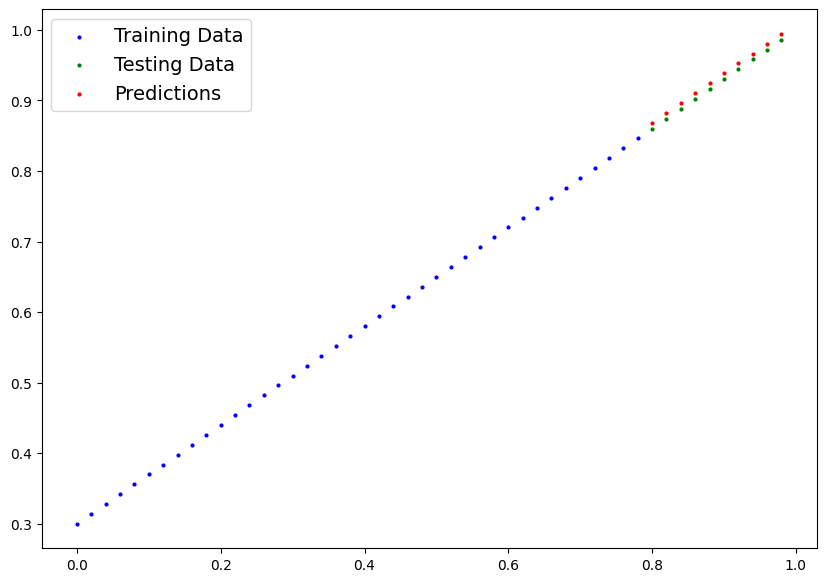

In [ ]:
with torch.inference_mode(): # turns off all gradient tracking
  y_preds_new=model_0(X_test)

plot_predictions(predictions=y_preds_new)

## Saving a model in python
There are 3 ways of saving and loading:
* torch.save()- saving pytorch object in python's pickle format
* torch.load()- allows to load saved pytorch object
* torch.nn.Module.load_state_dict()- allows to load model's saved state dictionary

In [ ]:
from pathlib import Path

#create model directory
MODEL_PATH=Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# create model save path
MODEL_NAME="01_pytorch_workflow.pth"
MODEL_SAVE_PATH=MODEL_PATH / MODEL_NAME

#save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow.pth


##Loading a pytorch model

since we saved our model's state dict rather than the entire model so we'll create a class of the model and load the state dict into that

In [ ]:
#To load saved state_dict we need to instantiate a new model of our model class
loaded_model_0=LinearRegressionModel()

#loading the saved state_dict
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH));

loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
#making some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds=loaded_model_0(X_test)
loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

#Putting Everything Together

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.9.0+cpu'

writing device agnostic code
i.e. if gpu is available then it will be used or else default cpu will be

In [ ]:
#setup device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
print("Device: ",device)


Device:  cpu


creating dummy data sets

In [ ]:
#using linear regression formula formula for creating data(y=weight*x+bias)
weight=0.7
bias=0.3

#create range values
start=0
end=1
step=0.02

#create x and y(features and labels)
x=torch.arange(start,end,step).unsqueeze(dim=1)#without unsqueeze errors will pop up
y=weight*x+bias
x[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
#split the data
train_split=int(0.8*len(x))
x_train,y_train=x[:train_split],y[:train_split]
x_test,y_test=x[train_split:],y[train_split:]
len(x_train),len(y_train),len(x_test),len(y_test)

(40, 40, 10, 10)

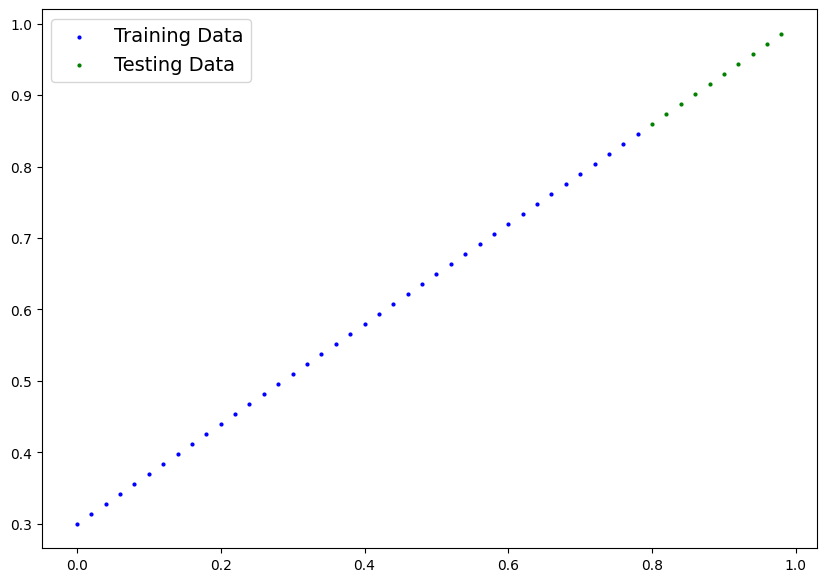

In [ ]:
#plot the data
plot_predictions(x_train,y_train,x_test,y_test)

In [ ]:
#create a linear model by subclassing nn.Module
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    #using nn.Linear() for creating the model parameters/ also called linear layer,fully connected layer,dense layer
    self.linear_layer=nn.Linear(in_features=1,
                                out_features=1)
  def forward(self,x:torch.Tensor)->torch.Tensor:
    return self.linear_layer(x)

#set the manual seed
torch.manual_seed(42)
model_1=LinearRegressionModelV2()
model_1,model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
#checking the device for the model
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
#setup the loss function
loss_fn=nn.L1Loss()

#setup optimizer
optimizer=torch.optim.SGD(params=model_1.parameters(),
                          lr=0.01)

In [ ]:
torch.manual_seed(42)

#writing the training loop
epochs=200
for epoch in range(epochs):
  model_1.train()
  y_pred=model_1(x_train)
  loss=loss_fn(y_pred,y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  #testing
  model_1.eval()
  with torch.inference_mode():
    test_pred=model_1(x_test)
    test_loss=loss_fn(test_pred,y_test)

  if epoch%10==0:
    print(f"Epoch: {epoch},Loss:{loss},Test Loss: {test_loss}")

Epoch: 0,Loss:0.5551779866218567,Test Loss: 0.5739762187004089
Epoch: 10,Loss:0.4399680495262146,Test Loss: 0.4392663538455963
Epoch: 20,Loss:0.3247582018375397,Test Loss: 0.30455657839775085
Epoch: 30,Loss:0.20954827964305878,Test Loss: 0.16984674334526062
Epoch: 40,Loss:0.09433844685554504,Test Loss: 0.03513689711689949
Epoch: 50,Loss:0.023886386305093765,Test Loss: 0.04784906655550003
Epoch: 60,Loss:0.0199567973613739,Test Loss: 0.04580312222242355
Epoch: 70,Loss:0.016517987474799156,Test Loss: 0.0375305712223053
Epoch: 80,Loss:0.013089170679450035,Test Loss: 0.029944902285933495
Epoch: 90,Loss:0.009653178043663502,Test Loss: 0.02167237363755703
Epoch: 100,Loss:0.006215679459273815,Test Loss: 0.014086711220443249
Epoch: 110,Loss:0.002787243574857712,Test Loss: 0.005814164876937866
Epoch: 120,Loss:0.0012645035749301314,Test Loss: 0.013801807537674904
Epoch: 130,Loss:0.0012645035749301314,Test Loss: 0.013801807537674904
Epoch: 140,Loss:0.0012645035749301314,Test Loss: 0.01380180753767